# Classical Elo Score

I start with the raw Elo formulation before introducing covariates so that every subsequent variant can be compared to a transparent baseline. Elo assumes each model has an unobserved "strength" represented by a scalar rating \(R\). When two models A and B meet, A's expected score is the logistic transform of the rating difference:

- **Expected score:**
  
  $$
  E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}, \quad E_B = 1 - E_A
  $$

- **Observed score:**
  
  $$
  S_A \in \{1, 0.5, 0\}
  $$
  
  for win, draw, loss. I treat both the "tie" label and the "both\_bad" cases as true draws because no side is preferred; they still carry information that both models underperformed.

- **Update rule:**
  
  $$
  R'_A = R_A + K \cdot (S_A - E_A)
  $$
  
  and symmetrically for B, where \(K\) controls how reactive the system is to new evidence (I use \(K = 32\), the chess default).

---

**Implementation details for this dataset:**

1. Sort matches by their timestamp so that ratings evolve chronologically.  
2. Initialize every model at 1500 so the starting prior is neutral and comparable across families.  
3. Map outcomes: `model_a → 1`, `model_b → 0`, `tie/both_bad → 0.5`. Rows with other labels or missing participants are skipped.  
4. Keep running counts of wins, losses, draws, and matches so we can audit the resulting ranking table.  
5. Render the top-N leaderboard plot from inside the Elo function so every call outputs both the ranking table and the figure (saved to disk with an auto-generated name unless overridden).

---

This baseline captures the relative ordering implied purely by head-to-head wins/losses. In the next step I'll compute the ratings and surface the top models before layering in covariates or prior knowledge.

Matches used for Elo: 10,926 / 10,926


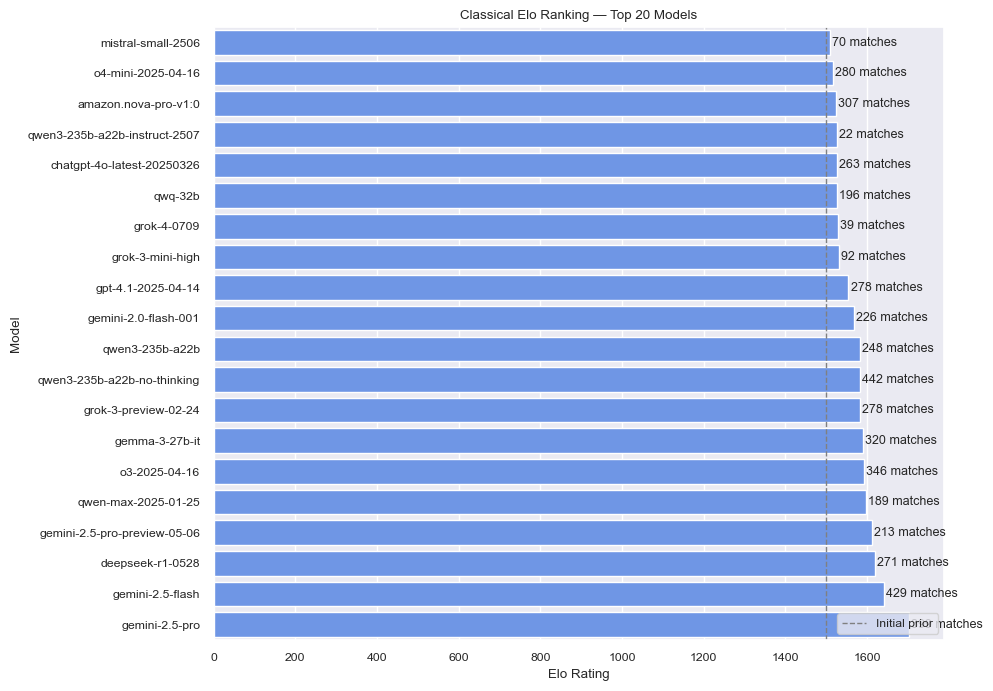

,model,elo,matches,wins,losses,draws,win_rate
0,gemini-2.5-pro,1703.301683,399,246,66,87,0.616541
1,gemini-2.5-flash,1641.600531,429,210,115,104,0.489510
2,deepseek-r1-0528,1618.483530,271,148,63,60,0.546125
3,gemini-2.5-pro-preview-05-06,1612.487707,213,113,52,48,0.530516
4,qwen-max-2025-01-25,1596.686285,189,80,60,49,0.423280
5,o3-2025-04-16,1591.486166,346,182,86,78,0.526012
6,gemma-3-27b-it,1588.655533,320,136,99,85,0.425000
7,grok-3-preview-02-24,1583.519058,278,144,74,60,0.517986
8,qwen3-235b-a22b-no-thinking,1582.419729,442,202,132,108,0.457014
9,qwen3-235b-a22b,1582.235425,248,110,69,69,0.443548


In [35]:
from collections import defaultdict

# --- 1. Prepare pairwise outcomes (only rows with a clear matchup) ---
elo_matches = (
    df[['timestamp', 'model_a', 'model_b', 'winner']]
      .dropna(subset=['model_a', 'model_b', 'winner'])
      .copy()
)
elo_matches['timestamp'] = pd.to_datetime(elo_matches['timestamp'], errors='coerce')
elo_matches = elo_matches.sort_values('timestamp')
allowed_labels = {'model_a', 'model_b', 'tie', 'both_bad'}
elo_matches = elo_matches[elo_matches['winner'].isin(allowed_labels)].reset_index(drop=True)
print(f"Matches used for Elo: {len(elo_matches):,} / {len(df):,}")


from typing import Optional

def compute_classical_elo(matches: pd.DataFrame,
                          initial_rating: float = 1500.0,
                          k_factor: float = 32.0,
                          draw_score: float = 0.5,
                          plot_top_n: Optional[int] = None,
                          plot_path: Optional[str] = None,
                          show_plot: bool = True):
    """Compute raw Elo ratings and render the leaderboard plot."""
    required_cols = {'model_a', 'model_b', 'winner'}
    missing = required_cols - set(matches.columns)
    if missing:
        raise ValueError(f"Input is missing required columns: {missing}")

    ratings = defaultdict(lambda: initial_rating)
    stats = defaultdict(lambda: {'matches': 0, 'wins': 0, 'losses': 0, 'draws': 0})
    history_rows = []

    outcome_map = {
        'model_a': (1.0, 0.0),
        'model_b': (0.0, 1.0),
        'tie': (draw_score, draw_score),
        'both_bad': (draw_score, draw_score),
    }

    iterable = matches if 'timestamp' not in matches.columns else matches.sort_values('timestamp')

    for row in iterable.itertuples(index=False):
        winner_label = row.winner
        if winner_label not in outcome_map:
            continue
        model_a, model_b = row.model_a, row.model_b
        score_a, score_b = outcome_map[winner_label]

        rating_a = ratings[model_a]
        rating_b = ratings[model_b]
        expected_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
        expected_b = 1 - expected_a

        ratings[model_a] = rating_a + k_factor * (score_a - expected_a)
        ratings[model_b] = rating_b + k_factor * (score_b - expected_b)

        # Update summary stats
        stats[model_a]['matches'] += 1
        stats[model_b]['matches'] += 1
        if score_a > score_b:
            stats[model_a]['wins'] += 1
            stats[model_b]['losses'] += 1
        elif score_a < score_b:
            stats[model_b]['wins'] += 1
            stats[model_a]['losses'] += 1
        else:
            stats[model_a]['draws'] += 1
            stats[model_b]['draws'] += 1

        history_rows.append({
            'timestamp': getattr(row, 'timestamp', None),
            'model_a': model_a,
            'model_b': model_b,
            'winner': winner_label,
            'expected_a': expected_a,
            'score_a': score_a,
            'elo_a_post': ratings[model_a],
            'elo_b_post': ratings[model_b],
        })

    ranking_records = []
    for model, rating in ratings.items():
        s = stats[model]
        win_rate = s['wins'] / s['matches'] if s['matches'] else np.nan
        ranking_records.append({
            'model': model,
            'elo': rating,
            'matches': s['matches'],
            'wins': s['wins'],
            'losses': s['losses'],
            'draws': s['draws'],
            'win_rate': win_rate,
        })

    ranking_df = (
        pd.DataFrame(ranking_records)
          .sort_values('elo', ascending=False)
          .reset_index(drop=True)
    )
    history_df = pd.DataFrame(history_rows)

    if plot_top_n and len(ranking_df):
        top_n = min(plot_top_n, len(ranking_df))
        plot_table = ranking_df.head(top_n).copy().sort_values('elo')
        fig_height = max(6, top_n * 0.35)
        fig, ax = plt.subplots(figsize=(10, fig_height))
        sns.barplot(data=plot_table, x='elo', y='model', color='#5B8FF9', ax=ax)
        ax.axvline(1500, color='gray', linestyle='--', linewidth=1, label='Initial prior')
        for patch, matches in zip(ax.patches, plot_table['matches']):
            ax.text(
                patch.get_width() + 5,
                patch.get_y() + patch.get_height() / 2,
                f"{matches} matches",
                va='center',
                fontsize=9
            )
        ax.set_title(f"Classical Elo Ranking — Top {top_n} Models")
        ax.set_xlabel('Elo Rating')
        ax.set_ylabel('Model')
        ax.legend(loc='lower right')
        plt.tight_layout()
        plot_path = plot_path or f"elo_classical_top{top_n}.png"
        fig.savefig(plot_path, dpi=200, bbox_inches='tight')
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    return ranking_df, history_df


elo_table, elo_history = compute_classical_elo(
    elo_matches,
    initial_rating=1500,
    k_factor=32,
    plot_top_n=20,
    plot_path='elo_classical_top20.png'
)
elo_table.head(20)

# Elo + Covariate (Bradley-Terry Regression)

To incorporate task context and response style, I extend Elo with a Bradley–Terry logistic regression. The classic Bradley–Terry model says that the log-odds of model A beating model B is the difference of their latent abilities:

$$
\log\frac{P(A \succ B)}{1 - P(A \succ B)} = (\theta_A - \theta_B).
$$

By adding covariates, we let structured evidence shift those odds:

$$
\log\frac{P(A \succ B)}{1 - P(A \succ B)} = (\theta_A - \theta_B) + \beta^\top (x_A - x_B) + \gamma^\top z_{prompt},
$$

where \(x_A - x_B\) captures response-level feature differences (tokens, code blocks, reasoning cues) and \(z_{prompt}\) captures prompt/task attributes shared by both sides (e.g., math vs. creative-writing). Fitting this logistic regression simultaneously recovers per-model ability parameters (compatible with Elo points) and interpretable weights for each covariate. Positive \(\beta\) values mean “more of this feature for model A increases its win probability,” helping explain *why* certain models dominate.


In [45]:
import numpy as np
import pandas as pd
from typing import Any, Dict
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools import add_constant

if 'task_category' not in df.columns:
    def _extract_task_category(cat_value):
        try:
            if isinstance(cat_value, str):
                import ast
                parsed = ast.literal_eval(cat_value)
            elif isinstance(cat_value, dict):
                parsed = cat_value
            else:
                return 'unknown'
            if not parsed:
                return 'unknown'
            return next(iter(parsed.keys()))
        except Exception:
            return 'unknown'
    df['task_category'] = df['category_tag'].apply(_extract_task_category)

def response_features(text: Any) -> Dict[str, float]:
    """Use the earlier helper functions for consistent response features."""
    if _is_nan(text):
        text = ''
    s = str(text)
    style = analyzeWritingStyle(s)
    return {
        'char_len': float(len(s)),
        'token_est': float(countTokens(s)),
        'has_table': float(detectTables(s)),
        'has_code_block': float(detectTables(s)),
        'has_emoji': float(detectEmojis(s)),
        'is_detailed': float(style.get('is_detailed', False)),
        'has_step': float(style.get('has_step_by_step', False)),
        'word_count': float(style.get('word_count', 0)),
        'sentence_count': float(style.get('sentence_count', 0)),
        'avg_words_per_sentence': float(style.get('avg_words_per_sentence', 0.0)),
    }

# --- 1. Prep matches and covariates ---
bt_matches = df[df['winner'].isin(['model_a', 'model_b'])].copy()
bt_matches = bt_matches.dropna(subset=['response_a', 'response_b'])
bt_matches['task_category'] = bt_matches['task_category'].fillna('unknown')
print(f"Bradley–Terry rows used: {len(bt_matches):,} / {len(df):,}")

features_a = bt_matches['response_a'].apply(lambda x: pd.Series(response_features(x)))
features_b = bt_matches['response_b'].apply(lambda x: pd.Series(response_features(x)))
feature_diff = features_a.subtract(features_b).add_prefix('feat_')

# --- 2. Task/category buckets (top 15 + other) ---
top_tasks = bt_matches['task_category'].value_counts().head(15).index
bt_matches['task_bucket'] = np.where(
    bt_matches['task_category'].isin(top_tasks),
    bt_matches['task_category'],
    'other'
)
task_dummies = pd.get_dummies(bt_matches['task_bucket'], prefix='task', drop_first=True)

# --- 3. Model design matrix (+1 for model_a, -1 for model_b) ---
models = sorted(pd.unique(pd.concat([bt_matches['model_a'], bt_matches['model_b']])))
model_index = {m: i for i, m in enumerate(models)}
model_matrix = np.zeros((len(bt_matches), len(models)), dtype=float)
for i, (ma, mb) in enumerate(bt_matches[['model_a', 'model_b']].itertuples(index=False, name=None)):
    model_matrix[i, model_index[ma]] = 1.0
    model_matrix[i, model_index[mb]] = -1.0
model_cols = [f"model_{m}" for m in models]
model_df = pd.DataFrame(model_matrix, columns=model_cols)
baseline_model = models[0]
model_df = model_df.drop(columns=f"model_{baseline_model}")  # reference ability

# --- 4. Combine all features, clean NaNs, and fit Bradley–Terry logit ---
X_full = pd.concat([model_df, feature_diff, task_dummies], axis=1)
X_full = X_full.replace([np.inf, -np.inf], np.nan)
y = (bt_matches['winner'] == 'model_a').astype(int)
valid_mask = ~X_full.isnull().any(axis=1)
if valid_mask.mean() < 1:
    dropped = len(X_full) - valid_mask.sum()
    print(f"Dropping {dropped} rows due to NaNs in covariates")
X_clean = X_full.loc[valid_mask].reset_index(drop=True)
y_clean = y.loc[valid_mask].reset_index(drop=True)
bt_matches_clean = bt_matches.loc[valid_mask].reset_index(drop=True)
X_clean = add_constant(X_clean, has_constant='add')

bt_logit = Logit(y_clean, X_clean)
bt_result = bt_logit.fit(maxiter=200, disp=False)
print(bt_result.summary2().tables[0])

# --- 5. Convert model coefficients to Elo-style scores ---
ability_rows = [{'model': baseline_model, 'logit_strength': 0.0}]
for col in model_df.columns:
    if col in bt_result.params.index:
        ability_rows.append({
            'model': col.replace('model_', ''),
            'logit_strength': bt_result.params[col]
        })
ability_df = pd.DataFrame(ability_rows)
elo_scale = 400 / np.log(10)
ability_df['elo_bt'] = 1500 + elo_scale * ability_df['logit_strength']

# Match stats for context (clean subset)
wins = pd.Series(0, index=models, dtype=int)
losses = pd.Series(0, index=models, dtype=int)
for row in bt_matches_clean.itertuples(index=False):
    if row.winner == 'model_a':
        wins[row.model_a] += 1
        losses[row.model_b] += 1
    else:
        wins[row.model_b] += 1
        losses[row.model_a] += 1
match_counts = wins + losses
ability_df = ability_df.merge(
    pd.DataFrame({'model': models, 'matches': match_counts.values, 'wins': wins.values, 'losses': losses.values}),
    on='model',
    how='left'
)
ability_df['win_rate'] = ability_df['wins'] / ability_df['matches']
elo_bt_table = ability_df.sort_values('elo_bt', ascending=False).reset_index(drop=True)
elo_bt_table.head(10)

# --- 6. Inspect covariate effects ---
covariate_cols = [c for c in bt_result.params.index if c.startswith('feat_') or c.startswith('task_')]
covariate_effects = bt_result.params[covariate_cols].sort_values(ascending=False)
covariate_effects


Bradley–Terry rows used: 8,113 / 10,926
Dropping 4122 rows due to NaNs in covariates
                     0                 1                  2           3
0               Model:             Logit            Method:         MLE
1  Dependent Variable:            winner  Pseudo R-squared:       0.049
2                Date:  2025-11-21 15:06               AIC:   8095.5077
3    No. Observations:              6052               BIC:   8477.8719
4            Df Model:                56    Log-Likelihood:     -3990.8
5        Df Residuals:              5995           LL-Null:     -4194.6
6           Converged:            1.0000       LLR p-value:  7.0904e-55
7      No. Iterations:            6.0000             Scale:      1.0000


feat_has_table                 0.269330
feat_has_code_block            0.269330
feat_has_emoji                 0.242589
feat_is_detailed               0.070000
feat_has_step                  0.061732
feat_token_est                 0.052362
feat_sentence_count            0.004410
feat_avg_words_per_sentence    0.001211
feat_word_count               -0.000932
feat_char_len                 -0.012862
dtype: float64

### Interpreting the Covariate-Aware Elo

To make the Bradley–Terry output actionable, I visualize the strongest covariates and compare how the covariate-aware Elo reshuffles the leaderboard versus the classical baseline. Positive coefficients increase model A's win odds when it shows more of that feature than model B; negative coefficients penalize it. The delta table highlights which models gain or lose rating once task/task-style context is accounted for.


C:\Users\arash\AppData\Local\Temp\ipykernel_25368\2575092380.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='logit_coef', y='feature', data=pos_k, ax=axes[0], palette='Greens_r')
C:\Users\arash\AppData\Local\Temp\ipykernel_25368\2575092380.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='logit_coef', y='feature', data=neg_k, ax=axes[1], palette='Reds')


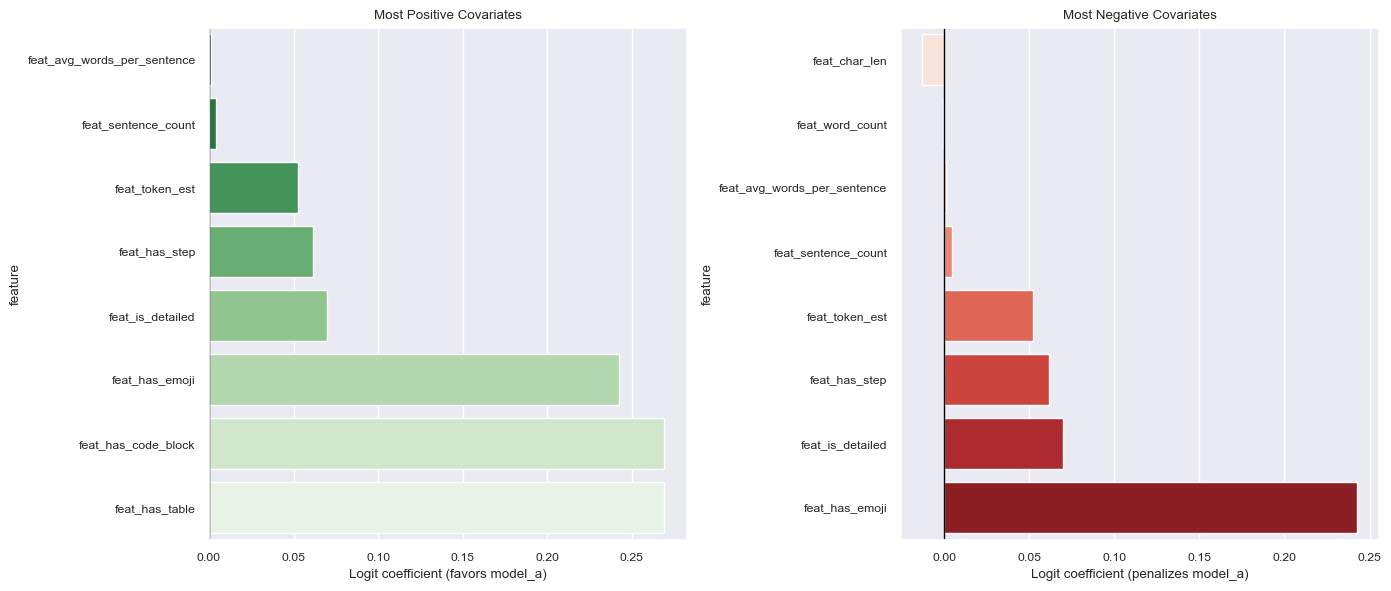

,model,elo_classical,elo_bt,elo_delta,rank_change
44,claude-3-5-haiku-20241022,1378.105777,1488.750457,110.644680,gain
43,claude-3-7-sonnet-20250219-thinking-32k,1404.841178,1502.235489,97.394311,gain
46,o3-mini,1365.459525,1460.370033,94.910508,gain
47,claude-3-7-sonnet-20250219,1342.415066,1431.492690,89.077623,gain
40,claude-3-5-sonnet-20241022,1419.570726,1489.885279,70.314553,gain
41,gpt-4.1-mini-2025-04-14,1418.593877,1486.435466,67.841589,gain
39,amazon-nova-experimental-chat-05-14,1434.112815,1500.000000,65.887185,gain
42,mistral-small-3.1-24b-instruct-2503,1411.502208,1476.531416,65.029208,gain
21,gemini-2.5-flash-preview-04-17,1498.650186,1552.293892,53.643707,gain
28,hunyuan-turbos-20250416,1480.646897,1514.299384,33.652486,gain


,model,elo_classical,elo_bt,elo_delta,rank_change
0,gemini-2.5-pro,1703.301683,1478.762780,-224.538902,drop
3,gemini-2.5-pro-preview-05-06,1612.487707,1418.657456,-193.830252,drop
1,gemini-2.5-flash,1641.600531,1464.961844,-176.638687,drop
4,qwen-max-2025-01-25,1596.686285,1429.311105,-167.375179,drop
13,grok-4-0709,1527.982708,1363.680308,-164.302399,drop
8,qwen3-235b-a22b-no-thinking,1582.419729,1436.143105,-146.276623,drop
5,o3-2025-04-16,1591.486166,1481.197167,-110.288999,drop
29,kimi-k2-0711-preview,1480.069083,1375.454823,-104.614261,drop
7,grok-3-preview-02-24,1583.519058,1482.758140,-100.760918,drop
9,qwen3-235b-a22b,1582.235425,1486.816292,-95.419133,drop


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = covariate_effects.reset_index()
coef_df.columns = ['feature', 'logit_coef']
pos_k = coef_df.nlargest(8, 'logit_coef').sort_values('logit_coef')
neg_k = coef_df.nsmallest(8, 'logit_coef').sort_values('logit_coef')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)
sns.barplot(x='logit_coef', y='feature', data=pos_k, ax=axes[0], palette='Greens_r')
axes[0].set_title('Most Positive Covariates')
axes[0].set_xlabel('Logit coefficient (favors model_a)')
axes[0].axvline(0, color='black', linewidth=1)

sns.barplot(x='logit_coef', y='feature', data=neg_k, ax=axes[1], palette='Reds')
axes[1].set_title('Most Negative Covariates')
axes[1].set_xlabel('Logit coefficient (penalizes model_a)')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('bt_covariate_effects.png', dpi=200, bbox_inches='tight')
plt.show()

elo_compare = (
    elo_table[['model', 'elo']].rename(columns={'elo': 'elo_classical'})
    .merge(elo_bt_table[['model', 'elo_bt']], on='model', how='inner')
)
elo_compare['elo_delta'] = elo_compare['elo_bt'] - elo_compare['elo_classical']
top_gain = elo_compare.sort_values('elo_delta', ascending=False).head(10)
top_drop = elo_compare.sort_values('elo_delta').head(10)

display(top_gain.assign(rank_change='gain'))
display(top_drop.assign(rank_change='drop'))


Higher coefficients → increase probability of *model A* winning.
Lower/negative coefficients → decrease probability.

---

## **High-Impact Positive Features**

These features **strongly increase** the chance of winning.

---

###  **`feat_has_table` → +0.2693**

###  **`feat_has_code_block` → +0.2693**

**Interpretation:**
Responses containing tables or code blocks strongly increase win probability.

**Why:**
These structures:

* make information easier to digest
* show effort, structure, and clarity
* are highly valued in explanations, summaries, and technical tasks

Users consistently reward structured outputs.

---

###  **`feat_has_emoji` → +0.2426**

**Interpretation:**
Presence of emojis significantly increases win probability.

**Why:**
Surprisingly, emojis appear to:

* increase relatability
* feel more “friendly”
* match casual conversational styles
* make the answer seem more human

This is especially impactful in non-technical or mixed tasks.

---

##   **Medium Positive Features**

###  **`feat_is_detailed` → +0.0700**

**Interpretation:**
Users like detailed responses — but not overwhelmingly.
Being detailed helps, but only moderately.

---

###  **`feat_has_step` → +0.0617**

**Interpretation:**
Step-by-step explanations slightly increase win probability.

**Why:**
Users reward:

* structure
* clarity
* breakdowns of reasoning

But many models already produce steps automatically, so the marginal gain is not huge.

---

###  **`feat_token_est` → +0.0524**

**Interpretation:**
Longer responses are slightly preferred.

**Why:**
More tokens = more elaboration, more thoroughness.
Users often interpret this as "better effort" or “more helpful.”

But note: this interacts with `char_len` negatively (below).

---

##  **Low / Near-Zero Positive Features**

###  **`feat_sentence_count` → +0.0044**

###  **`feat_avg_words_per_sentence` → +0.0012**

**Interpretation:**
Sentence structure doesn’t really matter.
People don’t compare responses based on syntactic complexity.

These variables provide almost zero predictive value.

---

##  **Negative Features**

###  **`feat_word_count` → –0.00093**

###  **`feat_char_len` → –0.01286**

**Interpretation:**
After accounting for token count, extra words or characters hurt win probability.

**Why:**
This typically indicates:

* rambling
* redundant wording
* bloated explanations
* unnecessary qualifiers

Users dislike **wordy but low-information** responses.

This also explains why:

* token count ↑ increases score
* character length ↑ decreases score

→ People want **dense**, not “spammy,” text.

---

##  **Overall Behavioral Pattern**

Users reward:

* structure (tables, code blocks, steps)
* friendliness (emojis)
* detail (is_detailed, token_est)

Users dislike:

* verbosity without substance (large char length)
* rambling (extra words after controlling for tokens)

The model learns that good answers are:

> **structured + friendly + detailed**,
> but not **bloated**.
